In [1]:
import sys
import os 

caminho_raiz = os.path.abspath(os.path.join('..'))
if caminho_raiz not in sys.path:
    sys.path.insert(0, caminho_raiz)

from src.dados import extrai_dataframe_dsc
from src.processamento_dsc import (
    convert_Celc2Kelvin, 
    separa_aquec_resf, 
    calc_pico_dsc,
    calc_tg_half_height,
    gerar_tabela_resultados
)

from src.visualizacao import plota_dsc
import matplotlib.pyplot as plt

## **VS55 - Hepes**

In [3]:
path_vs55_hepes_1 = "../dados/01_brutos/dsc/ExpDat_VS55_em_Hepes_allpoints.txt"
df_vs55_hepes_1 = extrai_dataframe_dsc(path_vs55_hepes_1)
df_vs55_hepes_1 = convert_Celc2Kelvin(df_vs55_hepes_1, "Temperatura (°C)")
display(df_vs55_hepes_1.head())

,Temperatura (K),Tempo (min),DSC (mW/mg),Sensibilidade (uV/mW),Segmento
0,298.38900,0.00000,0.041263,3.42562,1
1,298.38933,0.00333,0.041248,3.42562,1
2,298.38900,0.00667,0.041263,3.42562,1
3,298.38871,0.01000,0.041277,3.42562,1
4,298.38844,0.01333,0.041321,3.42562,1


In [4]:
df_vs55_hepes_1_resf, df_vs55_hepes_1_aquec = separa_aquec_resf(df_vs55_hepes_1)
print(f"Range aquec: {min(df_vs55_hepes_1_aquec.iloc[:, 0])}, {max(df_vs55_hepes_1_aquec.iloc[:, 0])}")
print(f"Range resf: {min(df_vs55_hepes_1_resf.iloc[:, 0])}, {max(df_vs55_hepes_1_resf.iloc[:, 0])}")

Range aquec: 102.76947999999999, 313.183
Range resf: 103.14299999999997, 298.38933


In [5]:
# [glassy], [rubbery], [inflexão]

PONTOS_AQUEC_VS55 = {
    "tg-aquec": {
        "pontos": ([140, 145], [165, 170], [152, 154]),
        "legenda": "Tg (Aquec.)"
    }, 
    "cristalizacao": {
        "tipo": "exo",
        "pontos": ([180, 190], [240, 250]),
        "legenda": "Tc, pico"
    },
    "melting": {
        "tipo": "endo",
        "pontos": ([180, 190], [240, 250]),
        "legenda": "Tm, pico"
    }
}

PONTOS_RESF_VS55 = {
    "tg-resf": {
        "pontos": ([153, 160], [125, 135], [142, 145]),
        "legenda": "Tg (Resf.)"
    }
} 

resultados_aquec = {}
resultados_resf = {}

for nome, dados in PONTOS_AQUEC_VS55.items():
    legenda = dados["legenda"]
    pontos = dados["pontos"]

    if "tipo" in dados:
        tipo = dados["tipo"]
        res = calc_pico_dsc(df_vs55_hepes_1_aquec, pontos, tipo)

    else:
        res = calc_tg_half_height(df_vs55_hepes_1_aquec, pontos=pontos)
    resultados_aquec[legenda] = res   


for nome, dados in PONTOS_RESF_VS55.items():
    legenda = dados["legenda"]
    pontos = dados["pontos"]

    res = calc_tg_half_height(df_vs55_hepes_1_resf, pontos=pontos)
    resultados_resf[legenda] = res


In [6]:
todos_resultados_vs55 = {**resultados_aquec, **resultados_resf}
pontos_plot = {}

for legenda, dados_evento in todos_resultados_vs55.items():
    
    if "Tg" in dados_evento:
        x_val = dados_evento["Tg"]
        y_val = dados_evento["HF_mid"]
        pontos_plot[legenda] = (x_val, y_val)
        
    elif "T_pico" in dados_evento:
        x_val = dados_evento["T_pico"]
        y_val = dados_evento["HF_pico"]
        pontos_plot[legenda] = (x_val, y_val)

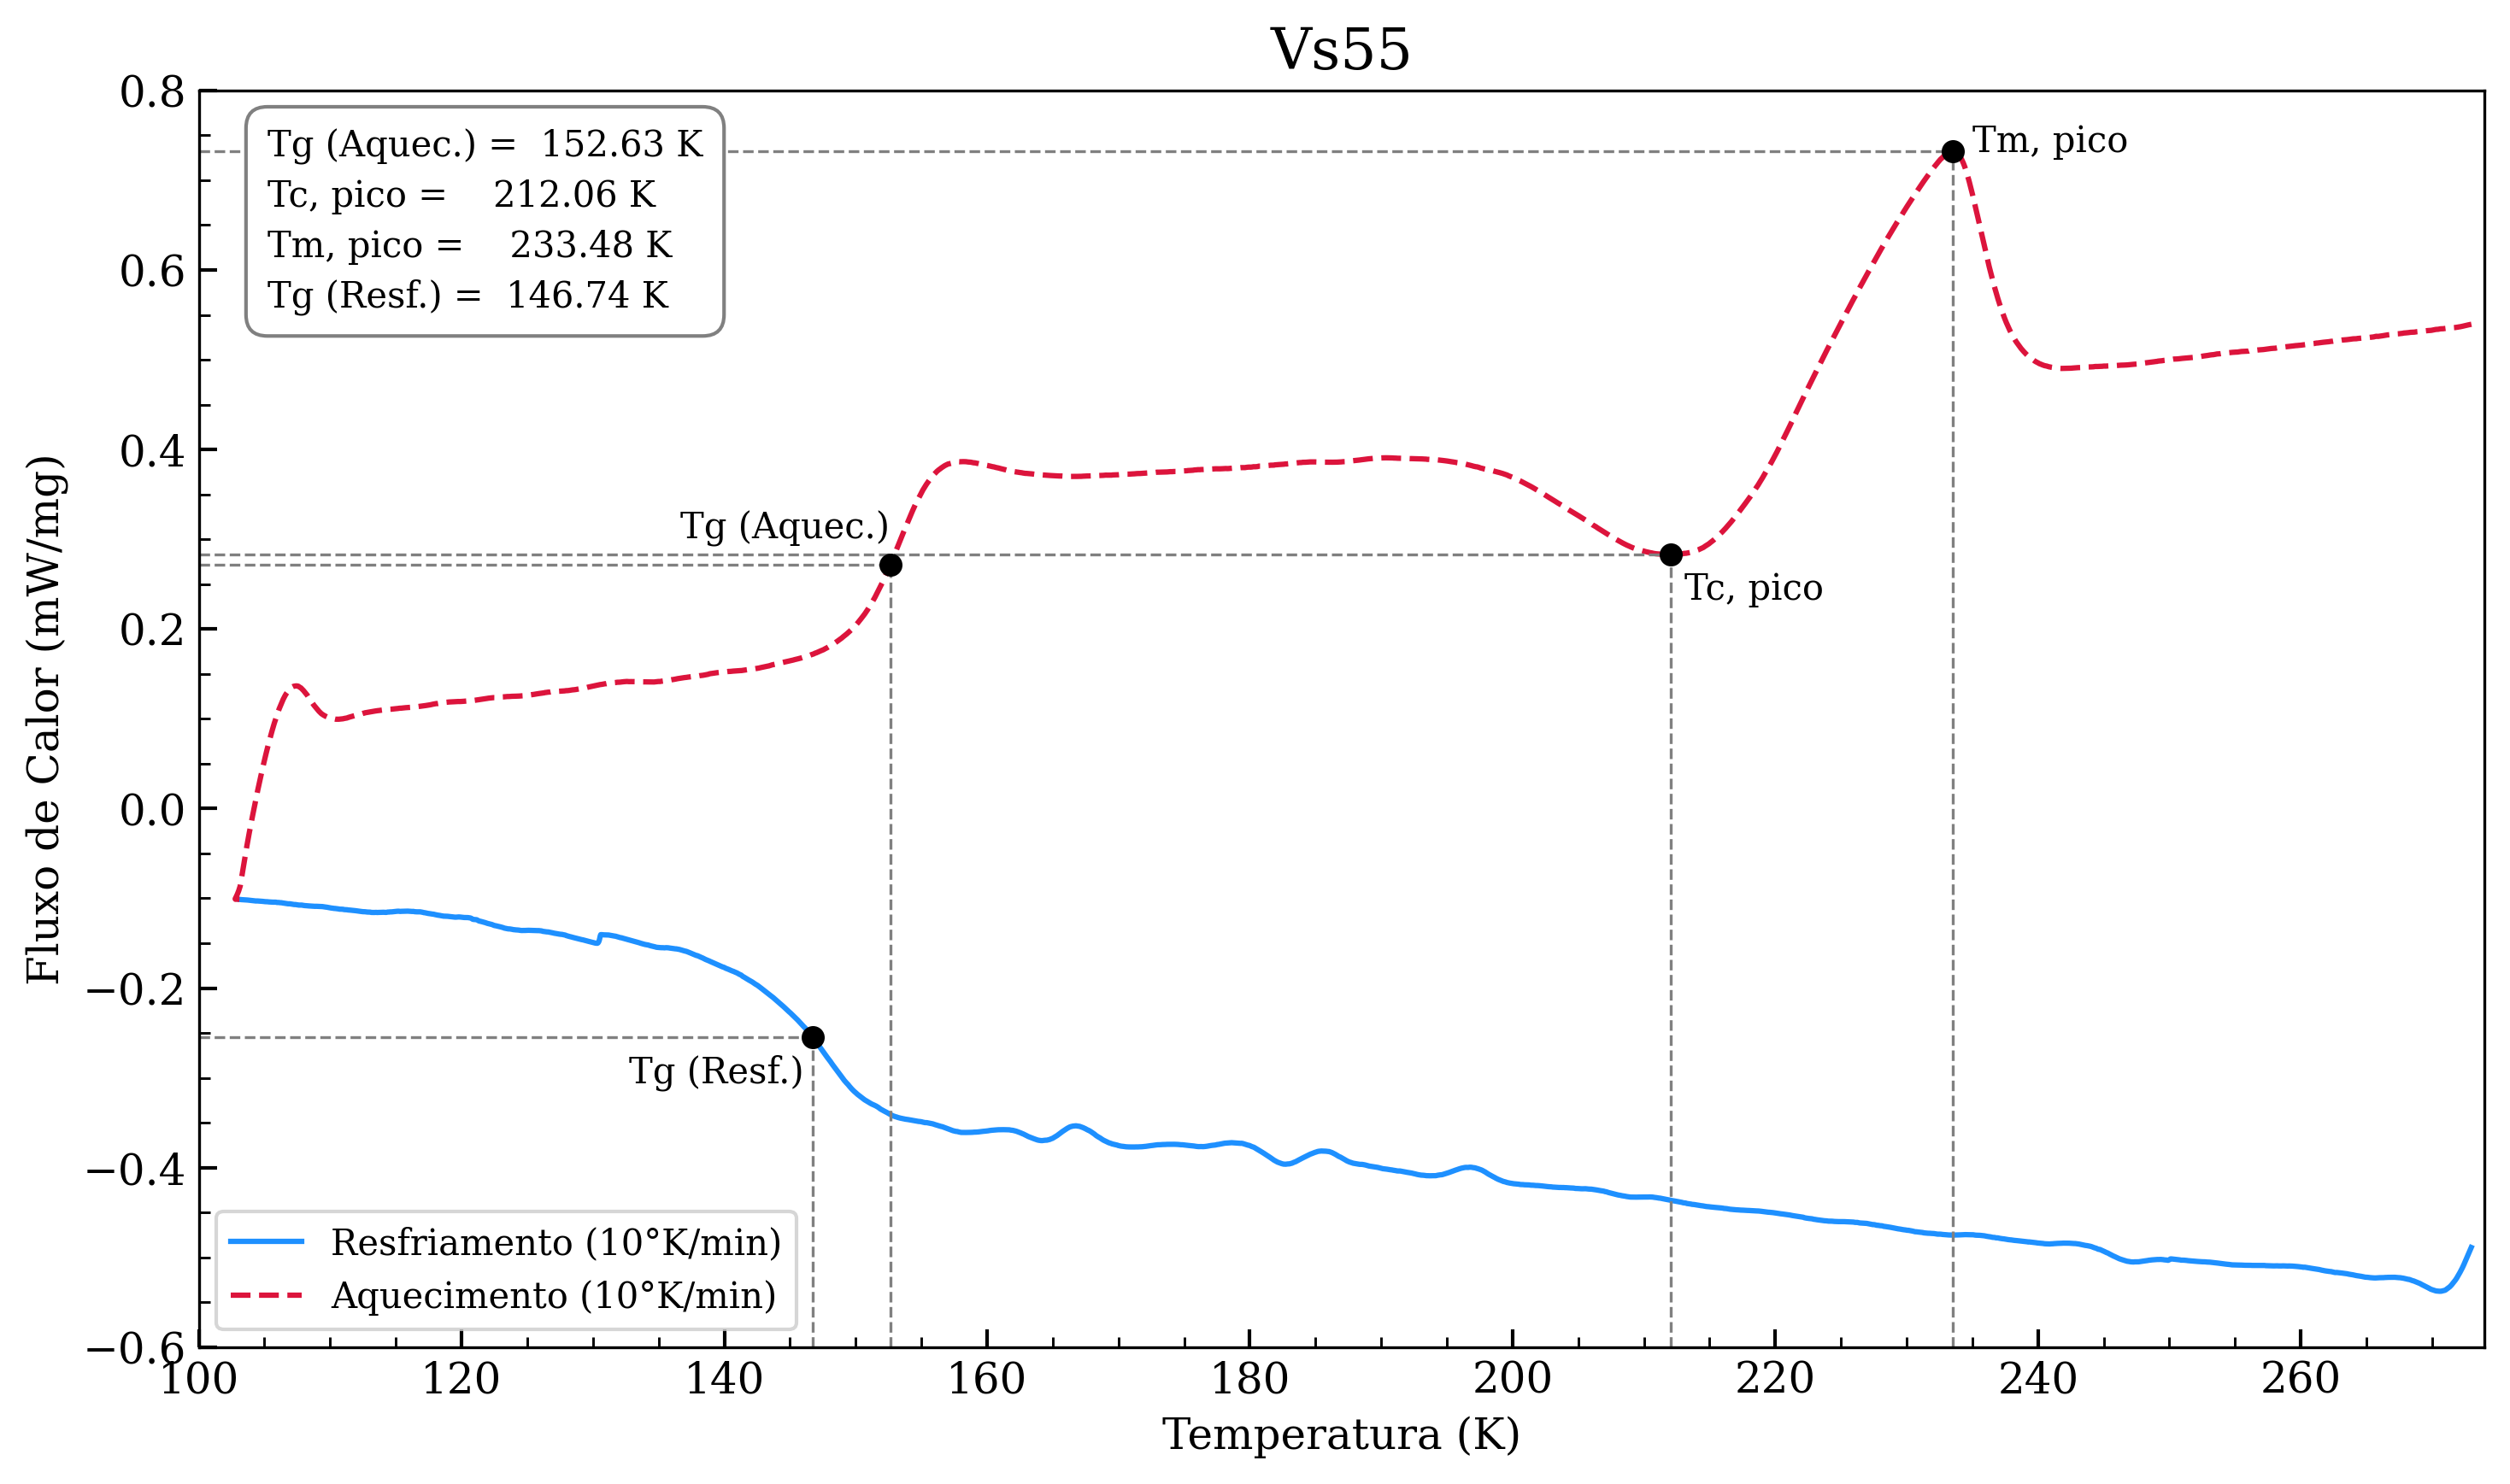

In [7]:
fig_vs55_hepes_1 = plota_dsc(
    titulo="Vs55",
    df_resf=df_vs55_hepes_1_resf, 
    df_aquec=df_vs55_hepes_1_aquec,
    range_temp_resf=(100, 273),
    range_temp_aquec=(100, 273),
    pontos=pontos_plot,
    y_lim=(-0.6, 0.8),
    x_lim=(100, 274),
    x_text_shifts=[-16, +1, +1.5, -14],
    y_text_shifts=[+0.03, -0.05, 0, -0.05],
    posicao_quadro=(0.03, 0.97)
)

path_vs55_hepes = "../resultados/dsc/plot_dsc_vs55_hepes_1.svg"
plt.savefig(path_vs55_hepes, format="svg", transparent=False, bbox_inches="tight", dpi=600)
plt.show() 

## **DP6 - Hepes**

In [8]:
path_dp6_hepes = "../dados/01_brutos/dsc/ExpDat_DPG_HEPES_allpoints.txt"
df_dp6_hepes = extrai_dataframe_dsc(path_dp6_hepes)
df_dp6_hepes = convert_Celc2Kelvin(df_dp6_hepes, "Temperatura (°C)")
display(df_dp6_hepes.head())

,Temperatura (K),Tempo (min),DSC (mW/mg),Sensibilidade (uV/mW),Segmento
0,298.15000,0.00000,0.089455,3.42573,1
1,298.14933,0.00333,0.089361,3.42573,1
2,298.14960,0.00667,0.089256,3.42573,1
3,298.14971,0.01000,0.089203,3.42573,1
4,298.15022,0.01333,0.089189,3.42573,1


In [9]:
df_dp6_hepes_resf, df_dp6_hepes_aquec = separa_aquec_resf(df_dp6_hepes)
print(f"Range aquec: {min(df_dp6_hepes_aquec.iloc[:, 0])}, {max(df_dp6_hepes_aquec.iloc[:, 0])}")
print(f"Range resf: {min(df_dp6_hepes_resf.iloc[:, 0])}, {max(df_dp6_hepes_resf.iloc[:, 0])}")

Range aquec: 102.75308999999999, 313.147
Range resf: 103.15196999999998, 298.15022


In [10]:
# [antes], [depois], [inflexão]

PONTOS_AQUEC_DP6 = {
    "tg-aquec": {
        "pontos": ([140, 145], [165, 170], [152, 154]),
        "legenda": "Tg (Aquec.)"
    }, 
    "cristalizacao": {
        "tipo": "exo",
        "pontos": ([180, 190], [240, 250]),
        "legenda": "Tc, pico"
    },
    "melting": {
        "tipo": "endo",
        "pontos": ([213, 220], [255, 265]),
        "legenda": "Tm, pico"
    }
}

PONTOS_RESF_DP6 = {
    "tg-resf": {
        "pontos": ([160, 170], [133, 137], [143, 154]),
        "legenda": "Tg (Resf.)"
    }
} 

resultados_aquec = {}
resultados_resf = {}

for nome, dados in PONTOS_AQUEC_DP6.items():
    legenda = dados["legenda"]
    pontos = dados["pontos"]

    if "tipo" in dados:
        tipo = dados["tipo"]
        res = calc_pico_dsc(df_dp6_hepes_aquec, pontos, tipo)

    else:
        res = calc_tg_half_height(df_dp6_hepes_aquec, pontos=pontos)
    resultados_aquec[legenda] = res   


for nome, dados in PONTOS_RESF_DP6.items():
    legenda = dados["legenda"]
    pontos = dados["pontos"]

    res = calc_tg_half_height(df_dp6_hepes_resf, pontos=pontos)
    resultados_resf[legenda] = res

print(resultados_resf)

{'Tg (Resf.)': {'Tg': np.float64(150.665433109357), 'T_ons': np.float64(156.40713452721943), 'T_end': np.float64(144.29406999578606), 'HF_ons': np.float64(-0.42225839565771767), 'HF_end': np.float64(-0.22314242253441463), 'HF_mid': np.float64(-0.3227004090960661)}}


In [11]:
todos_resultados_dp6 = {**resultados_aquec, **resultados_resf}
pontos_plot = {}

for legenda, dados_evento in todos_resultados_dp6.items():
    
    if "Tg" in dados_evento:
        x_val = dados_evento["Tg"]
        y_val = dados_evento["HF_mid"]
        pontos_plot[legenda] = (x_val, y_val)
        
    elif "T_pico" in dados_evento:
        x_val = dados_evento["T_pico"]
        y_val = dados_evento["HF_pico"]
        pontos_plot[legenda] = (x_val, y_val)

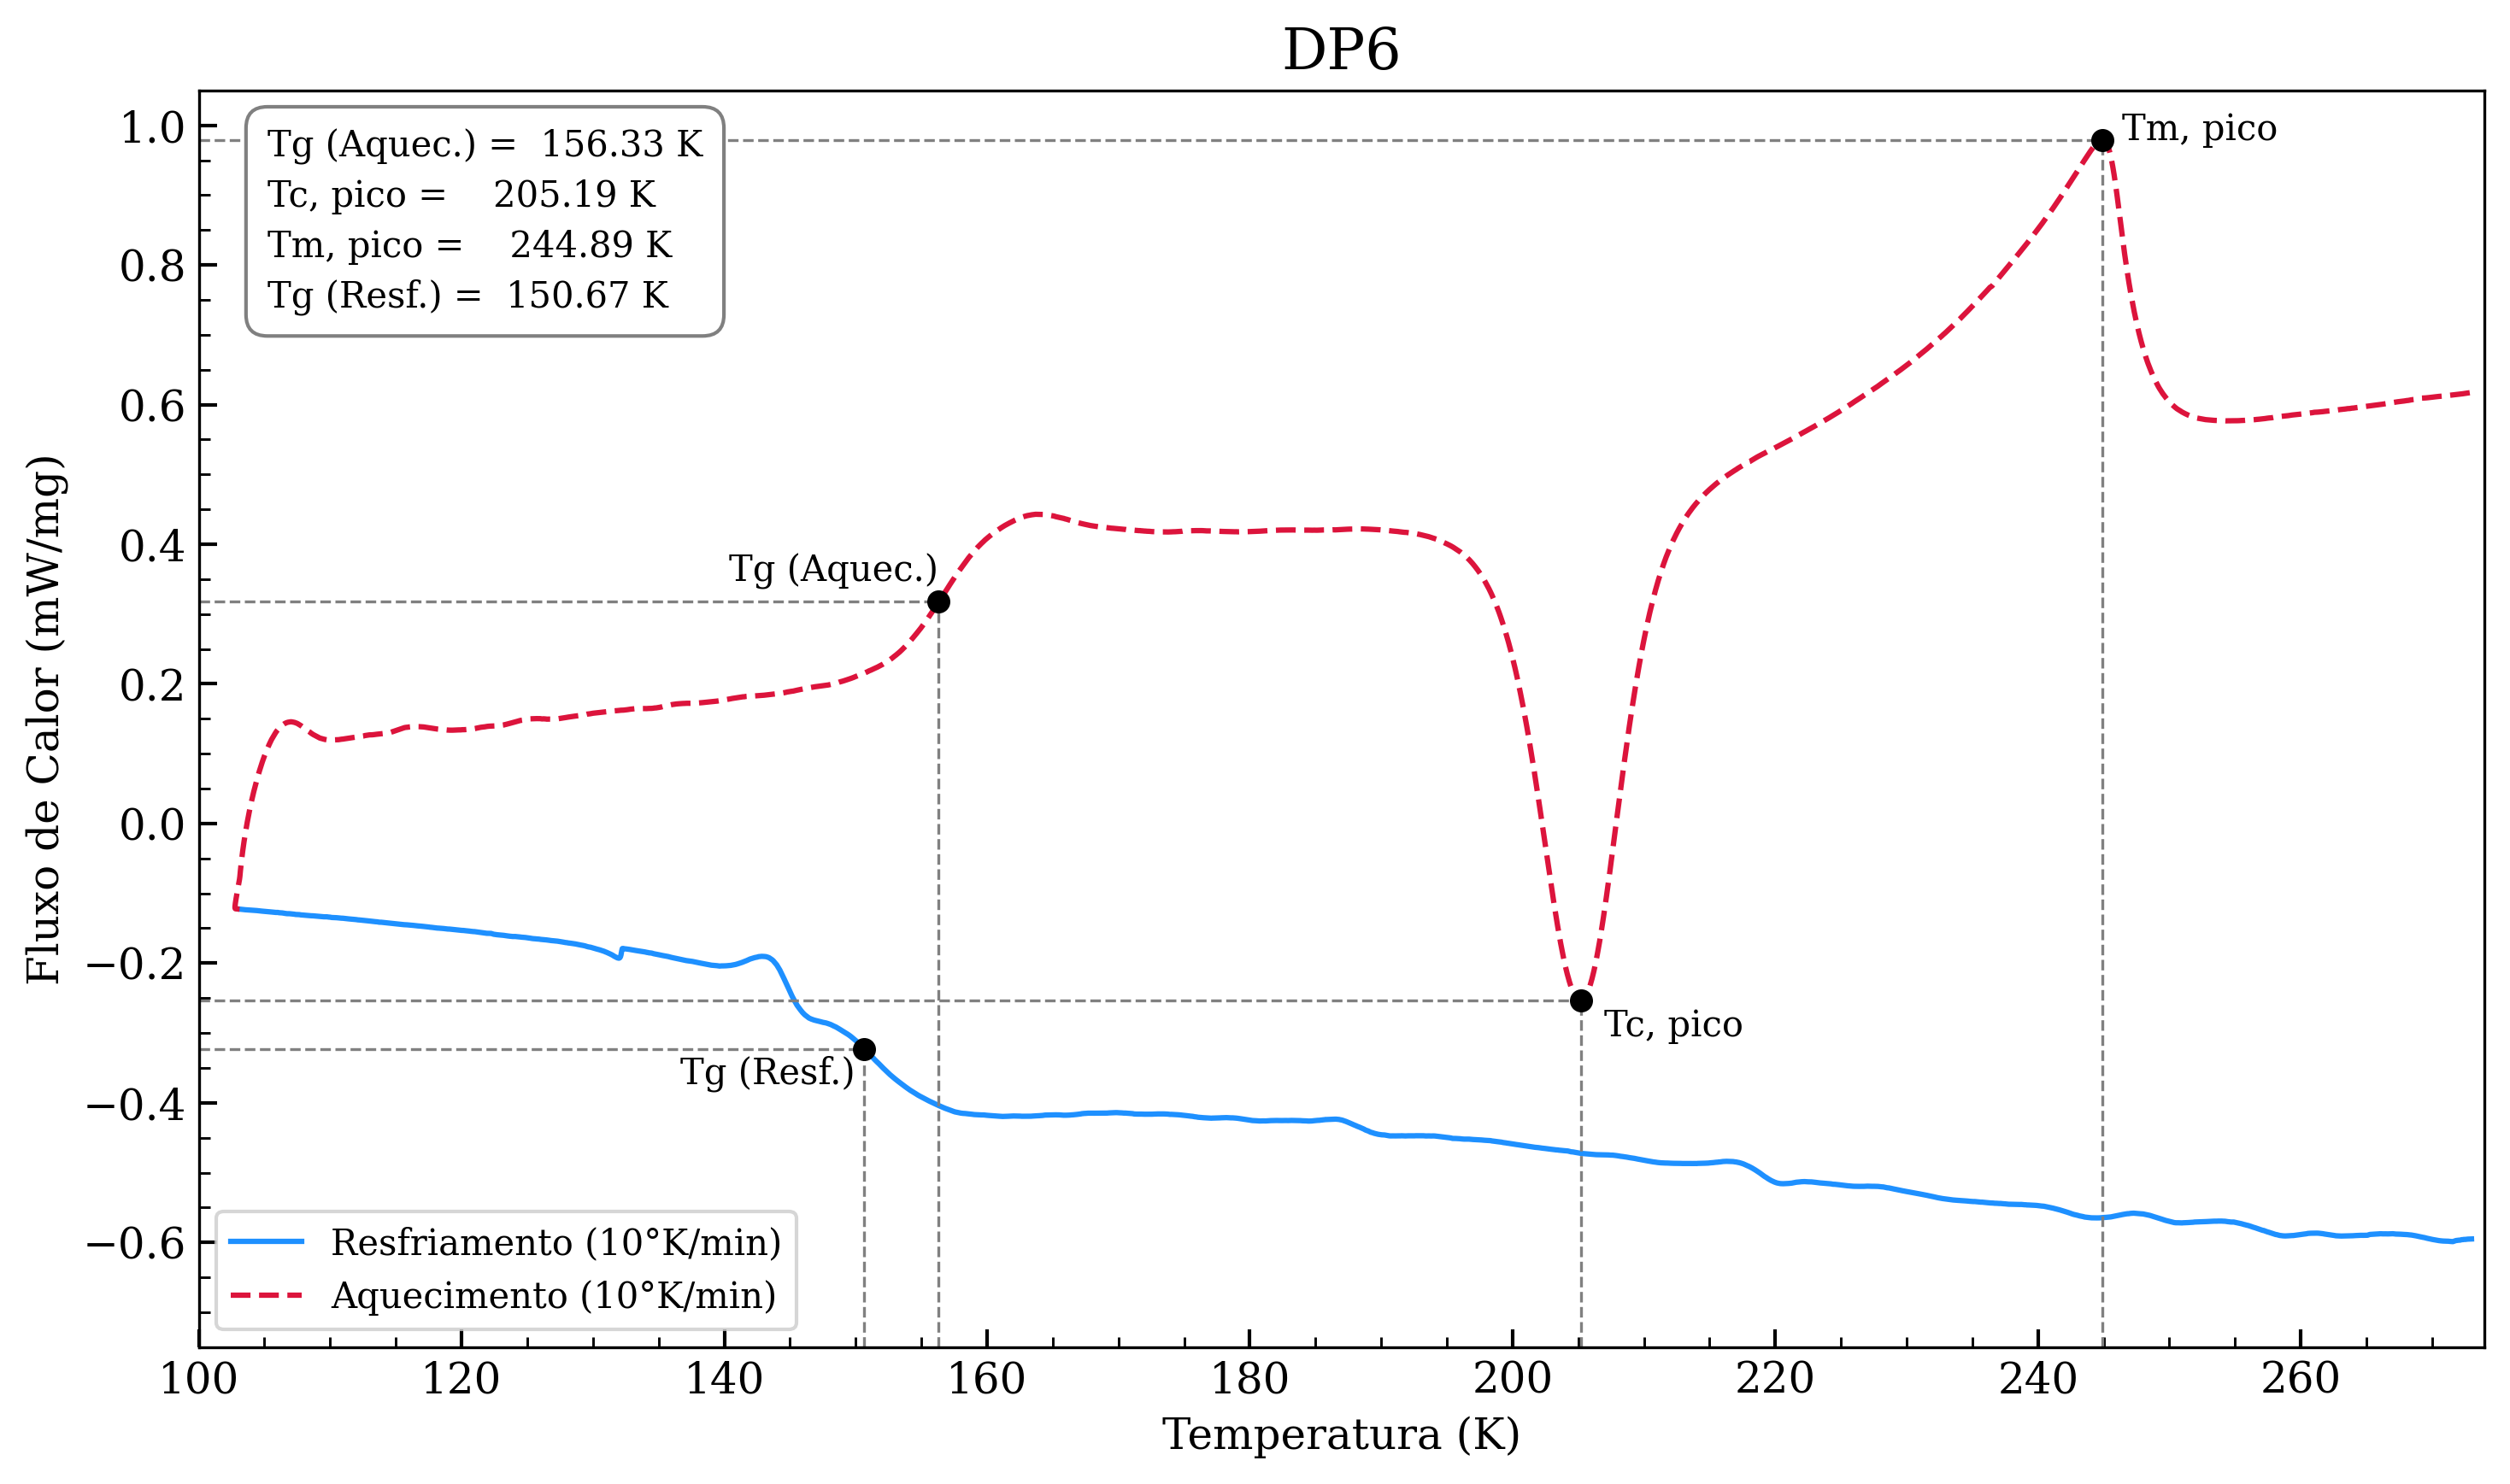

In [12]:
fig_dp6_hepes = plota_dsc(
    titulo="DP6",
    df_resf=df_dp6_hepes_resf, 
    df_aquec=df_dp6_hepes_aquec,
    range_temp_resf=(100, 273),
    range_temp_aquec=(100, 273),
    pontos=pontos_plot,
    y_lim=(-0.75, 1.05),
    x_lim=(100, 274),
    x_text_shifts=[-16, +1.8, +1.5, -14],
    y_text_shifts=[+0.03, -0.05, 0, -0.05],
    posicao_quadro=(0.03, 0.97)
)

path_dp6_hepes = "../resultados/dsc/plot_dsc_dp6_hepes.svg"
plt.savefig(path_dp6_hepes, format="svg", transparent=False, bbox_inches="tight", dpi=600)
plt.show() 

## **VEG - Hepes**

In [13]:
path_veg_hepes = "../dados/01_brutos/dsc/ExpDat_VEG_HEPES_allpoints.txt"
df_veg_hepes = extrai_dataframe_dsc(path_veg_hepes)
df_veg_hepes = convert_Celc2Kelvin(df_veg_hepes, "Temperatura (°C)")
display(df_veg_hepes.head())

,Temperatura (K),Tempo (min),DSC (mW/mg),Sensibilidade (uV/mW),Segmento
0,298.14500,0.00000,0.064018,3.42574,1
1,298.14633,0.00333,0.063967,3.42573,1
2,298.14700,0.00667,0.063928,3.42573,1
3,298.14714,0.01000,0.063903,3.42573,1
4,298.14722,0.01333,0.063890,3.42573,1


In [14]:
df_veg_hepes_resf, df_veg_hepes_aquec = separa_aquec_resf(df_veg_hepes)
print(f"Range aquec: {min(df_veg_hepes_aquec.iloc[:, 0])}, {max(df_veg_hepes_aquec.iloc[:, 0])}")
print(f"Range resf: {min(df_veg_hepes_resf.iloc[:, 0])}, {max(df_veg_hepes_resf.iloc[:, 0])}")

Range aquec: 102.76726999999997, 313.118
Range resf: 103.14854999999997, 298.14723


In [15]:
# [antes], [depois], [inflexão]

PONTOS_AQUEC_VEG = {
    "tg-aquec": {
        "pontos": ([130, 140], [155, 160], [145, 150]),
        "legenda": "Tg (Aquec.)"
    }, 
    "cristalizacao": {
        "tipo": "exo",
        "pontos": ([170, 182], [208, 215]),
        "legenda": "Tc, pico"
    },
    "melting": {
        "tipo": "endo",
        "pontos": ([213, 220], [245, 255]),
        "legenda": "Tm, pico"
    }
}

PONTOS_RESF_VEG = {
    "tg-resf": {
        "pontos": ([147, 160], [110, 125], [140, 146]),
        "legenda": "Tg (Resf.)"
    }
} 

resultados_aquec = {}
resultados_resf = {}

for nome, dados in PONTOS_AQUEC_VEG.items():
    legenda = dados["legenda"]
    pontos = dados["pontos"]

    if "tipo" in dados:
        tipo = dados["tipo"]
        res = calc_pico_dsc(df_veg_hepes_aquec, pontos, tipo)

    else:
        res = calc_tg_half_height(df_veg_hepes_aquec, pontos=pontos)
    resultados_aquec[legenda] = res   


for nome, dados in PONTOS_RESF_VEG.items():
    legenda = dados["legenda"]
    pontos = dados["pontos"]

    res = calc_tg_half_height(df_veg_hepes_resf, pontos=pontos)
    resultados_resf[legenda] = res

print(resultados_resf)

{'Tg (Resf.)': {'Tg': np.float64(142.32174472711273), 'T_ons': np.float64(145.58878904828111), 'T_end': np.float64(137.69753695908292), 'HF_ons': np.float64(-0.32771256735336596), 'HF_end': np.float64(-0.1703994730103779), 'HF_mid': np.float64(-0.24905602018187192)}}


In [16]:
todos_resultados_veg = {**resultados_aquec, **resultados_resf}
pontos_plot = {}

for legenda, dados_evento in todos_resultados_veg.items():
    
    if "Tg" in dados_evento:
        x_val = dados_evento["Tg"]
        y_val = dados_evento["HF_mid"]
        pontos_plot[legenda] = (x_val, y_val)
        
    elif "T_pico" in dados_evento:
        x_val = dados_evento["T_pico"]
        y_val = dados_evento["HF_pico"]
        pontos_plot[legenda] = (x_val, y_val)

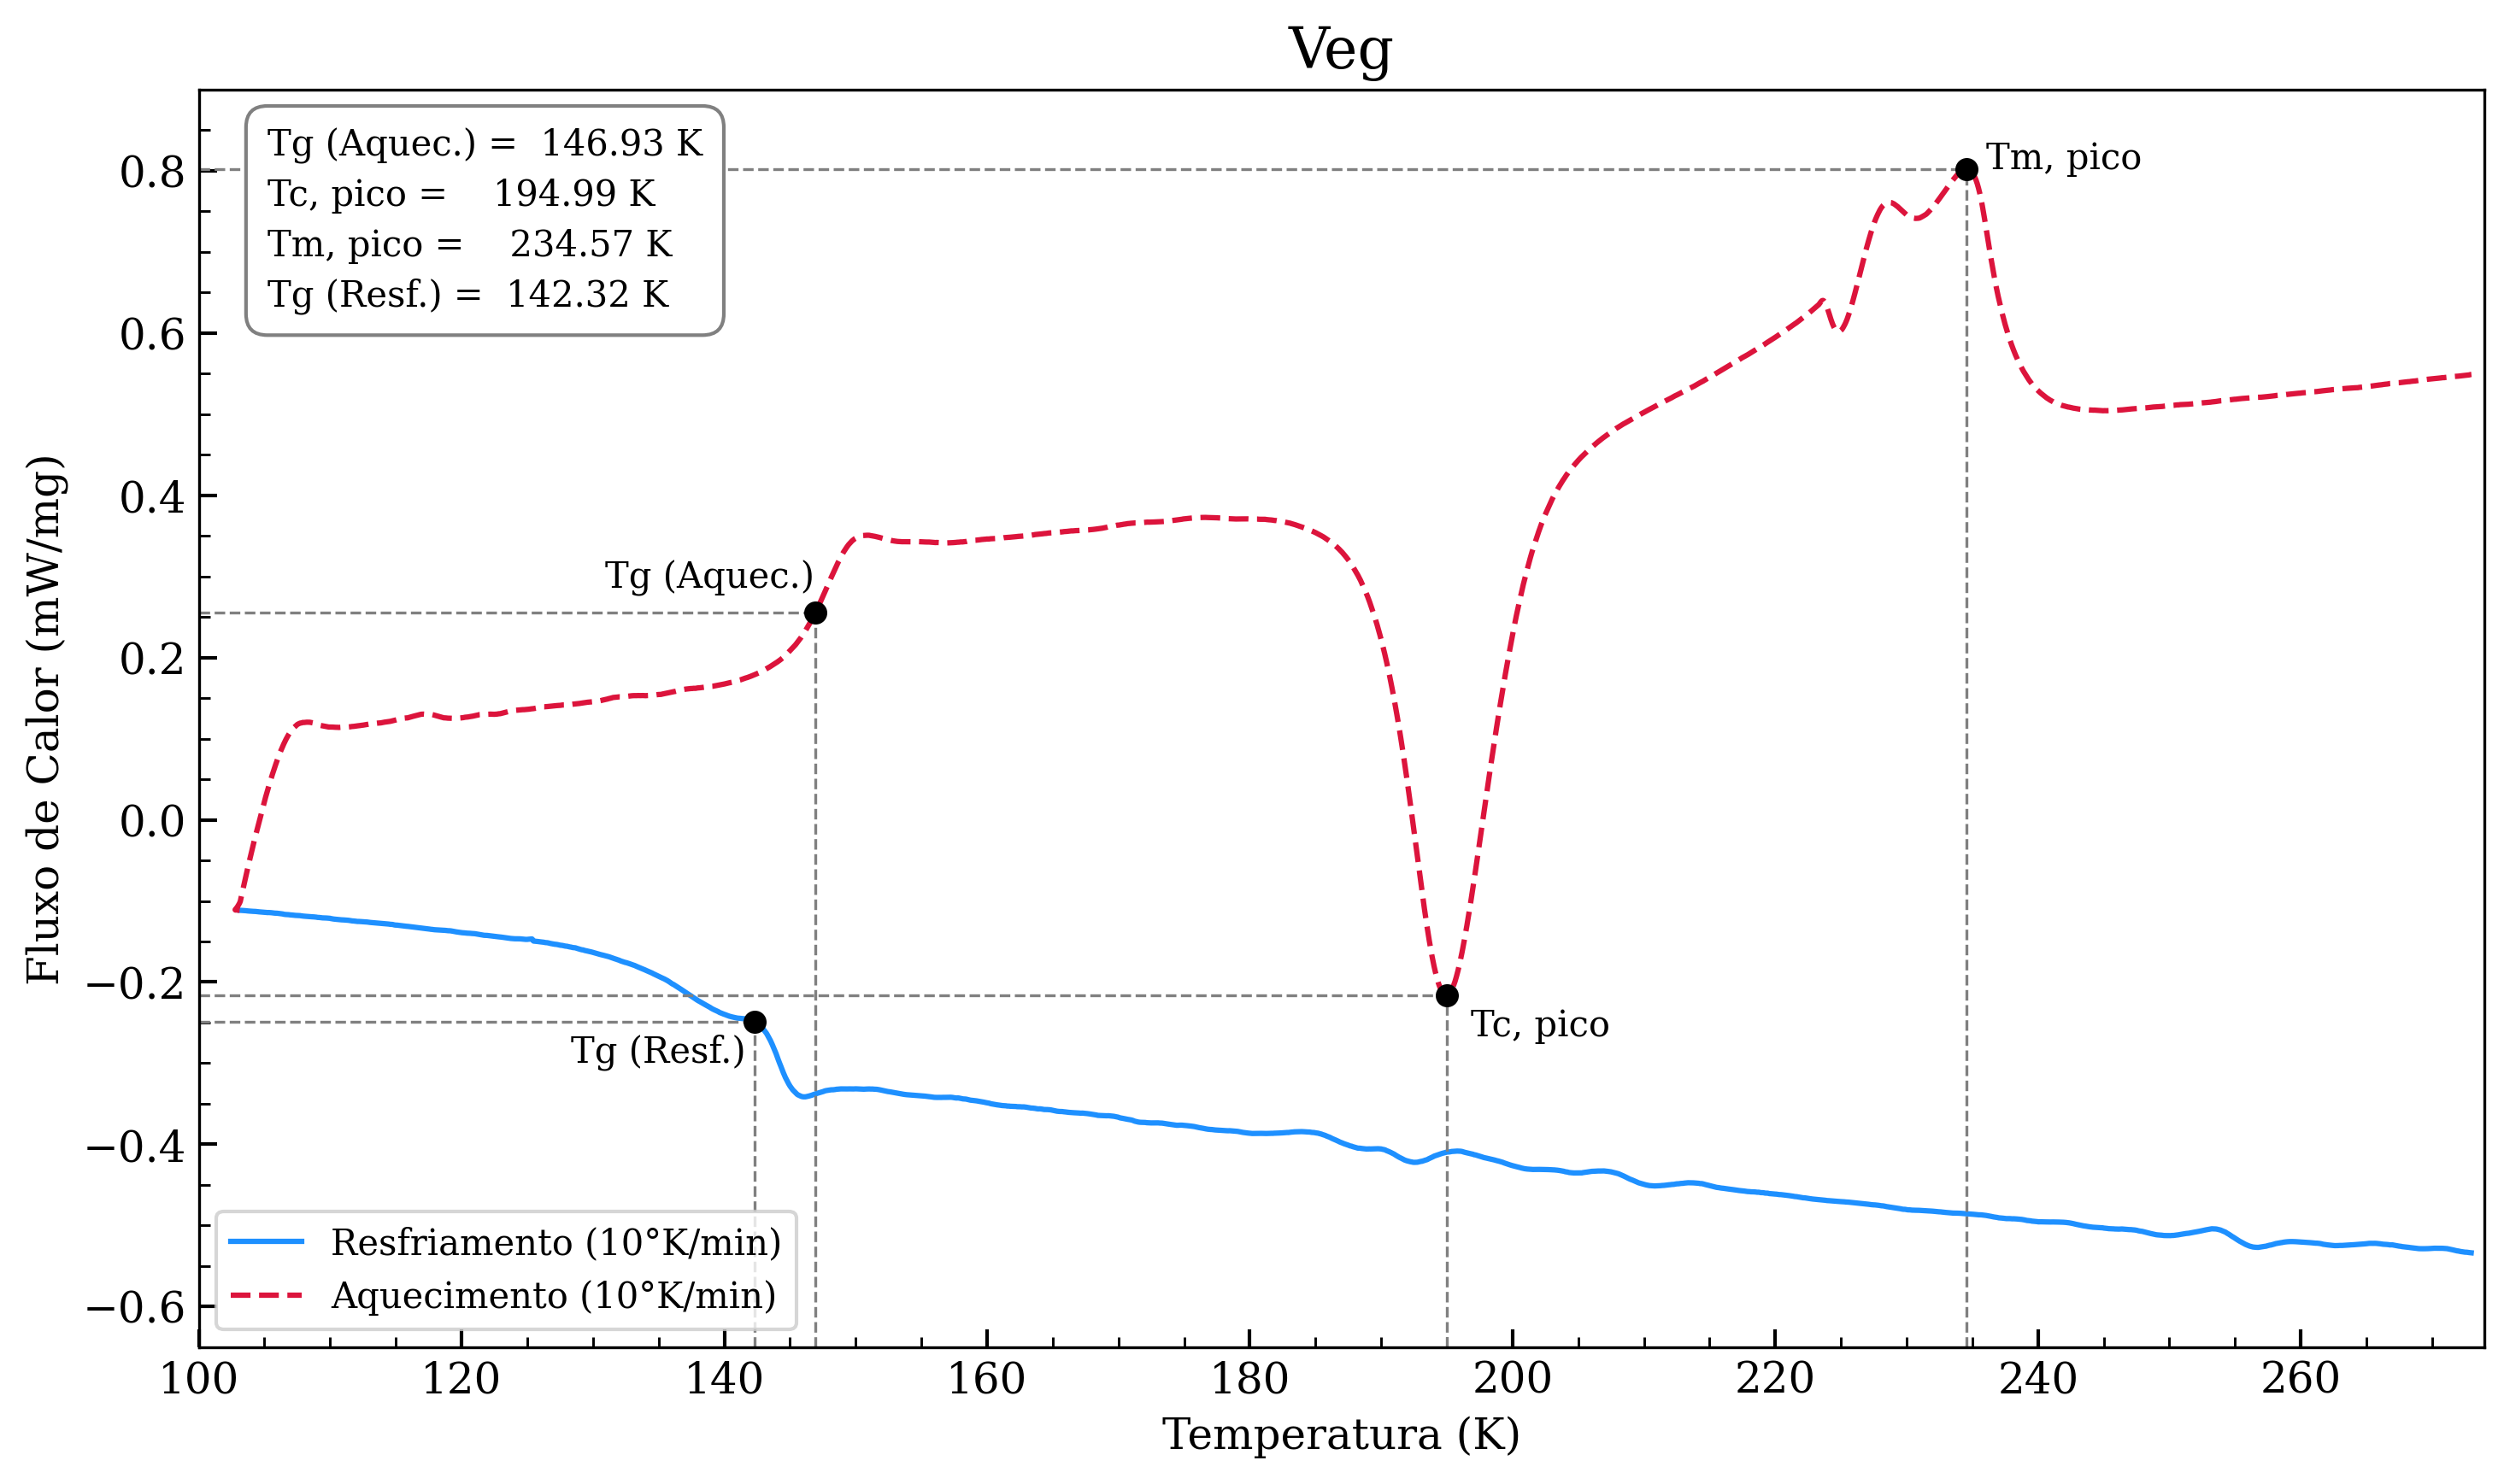

In [17]:
fig_veg_hepes = plota_dsc(
    titulo="Veg",
    df_resf=df_veg_hepes_resf, 
    df_aquec=df_veg_hepes_aquec,
    range_temp_resf=(100, 273),
    range_temp_aquec=(100, 273),
    pontos=pontos_plot,
    y_lim=(-0.65, 0.9),
    x_lim=(100, 274),
    x_text_shifts=[-16, +1.8, +1.5, -14],
    y_text_shifts=[+0.03, -0.05, 0, -0.05],
    posicao_quadro=(0.03, 0.97)
)

path_veg_hepes = "../resultados/dsc/plot_dsc_veg_hepes.svg"
plt.savefig(path_veg_hepes, format="svg", transparent=False, bbox_inches="tight", dpi=600)
plt.show() 

## **Glycerol - Hepes**

In [18]:
path_gly_hepes = "../dados/01_brutos/dsc/ExpDat_GLICEROL_GM_HEPES_allpoints.txt"
df_gly_hepes = extrai_dataframe_dsc(path_gly_hepes)
df_gly_hepes = convert_Celc2Kelvin(df_gly_hepes, "Temperatura (°C)")
display(df_gly_hepes.head())

,Temperatura (K),Tempo (min),DSC (mW/mg),Sensibilidade (uV/mW),Segmento
0,298.14700,0.00000,0.034936,3.42573,1
1,298.14581,0.00268,0.034884,3.42574,1
2,298.14571,0.00535,0.034849,3.42574,1
3,298.14571,0.00803,0.034823,3.42574,1
4,298.14563,0.01070,0.034789,3.42574,1


In [19]:
df_gly_hepes_resf, df_gly_hepes_aquec = separa_aquec_resf(df_gly_hepes)
print(f"Range aquec: {min(df_gly_hepes_aquec.iloc[:, 0])}, {max(df_gly_hepes_aquec.iloc[:, 0])}")
print(f"Range resf: {min(df_gly_hepes_resf.iloc[:, 0])}, {max(df_gly_hepes_resf.iloc[:, 0])}")

Range aquec: 102.75248999999997, 313.13282999999996
Range resf: 103.14126999999996, 298.147


In [20]:
# [antes], [depois], [inflexão]

PONTOS_AQUEC_GLY = {
    "tg-aquec": {
        "pontos": ([140, 153], [166, 176], [158, 164]),
        "legenda": "Tg (Aquec.)"
    }, 
    "cristalizacao": {
        "tipo": "exo",
        "pontos": ([158, 164], [193, 203]),
        "legenda": "Tc, pico"
    },
    "melting": {
        "tipo": "endo",
        "pontos": ([215, 220], [256, 266]),
        "legenda": "Tm, pico"
    }
}

PONTOS_RESF_GLY = {
    "tg-resf": {
        "pontos": ([160, 170], [130, 135], [141, 155]),
        "legenda": "Tg (Resf.)"
    }
} 

resultados_aquec = {}
resultados_resf = {}

for nome, dados in PONTOS_AQUEC_GLY.items():
    legenda = dados["legenda"]
    pontos = dados["pontos"]

    if "tipo" in dados:
        tipo = dados["tipo"]
        res = calc_pico_dsc(df_gly_hepes_aquec, pontos, tipo)

    else:
        res = calc_tg_half_height(df_gly_hepes_aquec, pontos=pontos)
    resultados_aquec[legenda] = res   


for nome, dados in PONTOS_RESF_GLY.items():
    legenda = dados["legenda"]
    pontos = dados["pontos"]

    res = calc_tg_half_height(df_gly_hepes_resf, pontos=pontos)
    resultados_resf[legenda] = res

print(resultados_resf)

{'Tg (Resf.)': {'Tg': np.float64(154.78096097041097), 'T_ons': np.float64(167.12704241429014), 'T_end': np.float64(144.59345790378657), 'HF_ons': np.float64(-0.3805773308179539), 'HF_end': np.float64(-0.19738152125295771), 'HF_mid': np.float64(-0.2889794260354558)}}


In [21]:
todos_resultados_gly = {**resultados_aquec, **resultados_resf}
pontos_plot = {}

for legenda, dados_evento in todos_resultados_gly.items():
    
    if "Tg" in dados_evento:
        x_val = dados_evento["Tg"]
        y_val = dados_evento["HF_mid"]
        pontos_plot[legenda] = (x_val, y_val)
        
    elif "T_pico" in dados_evento:
        x_val = dados_evento["T_pico"]
        y_val = dados_evento["HF_pico"]
        pontos_plot[legenda] = (x_val, y_val)

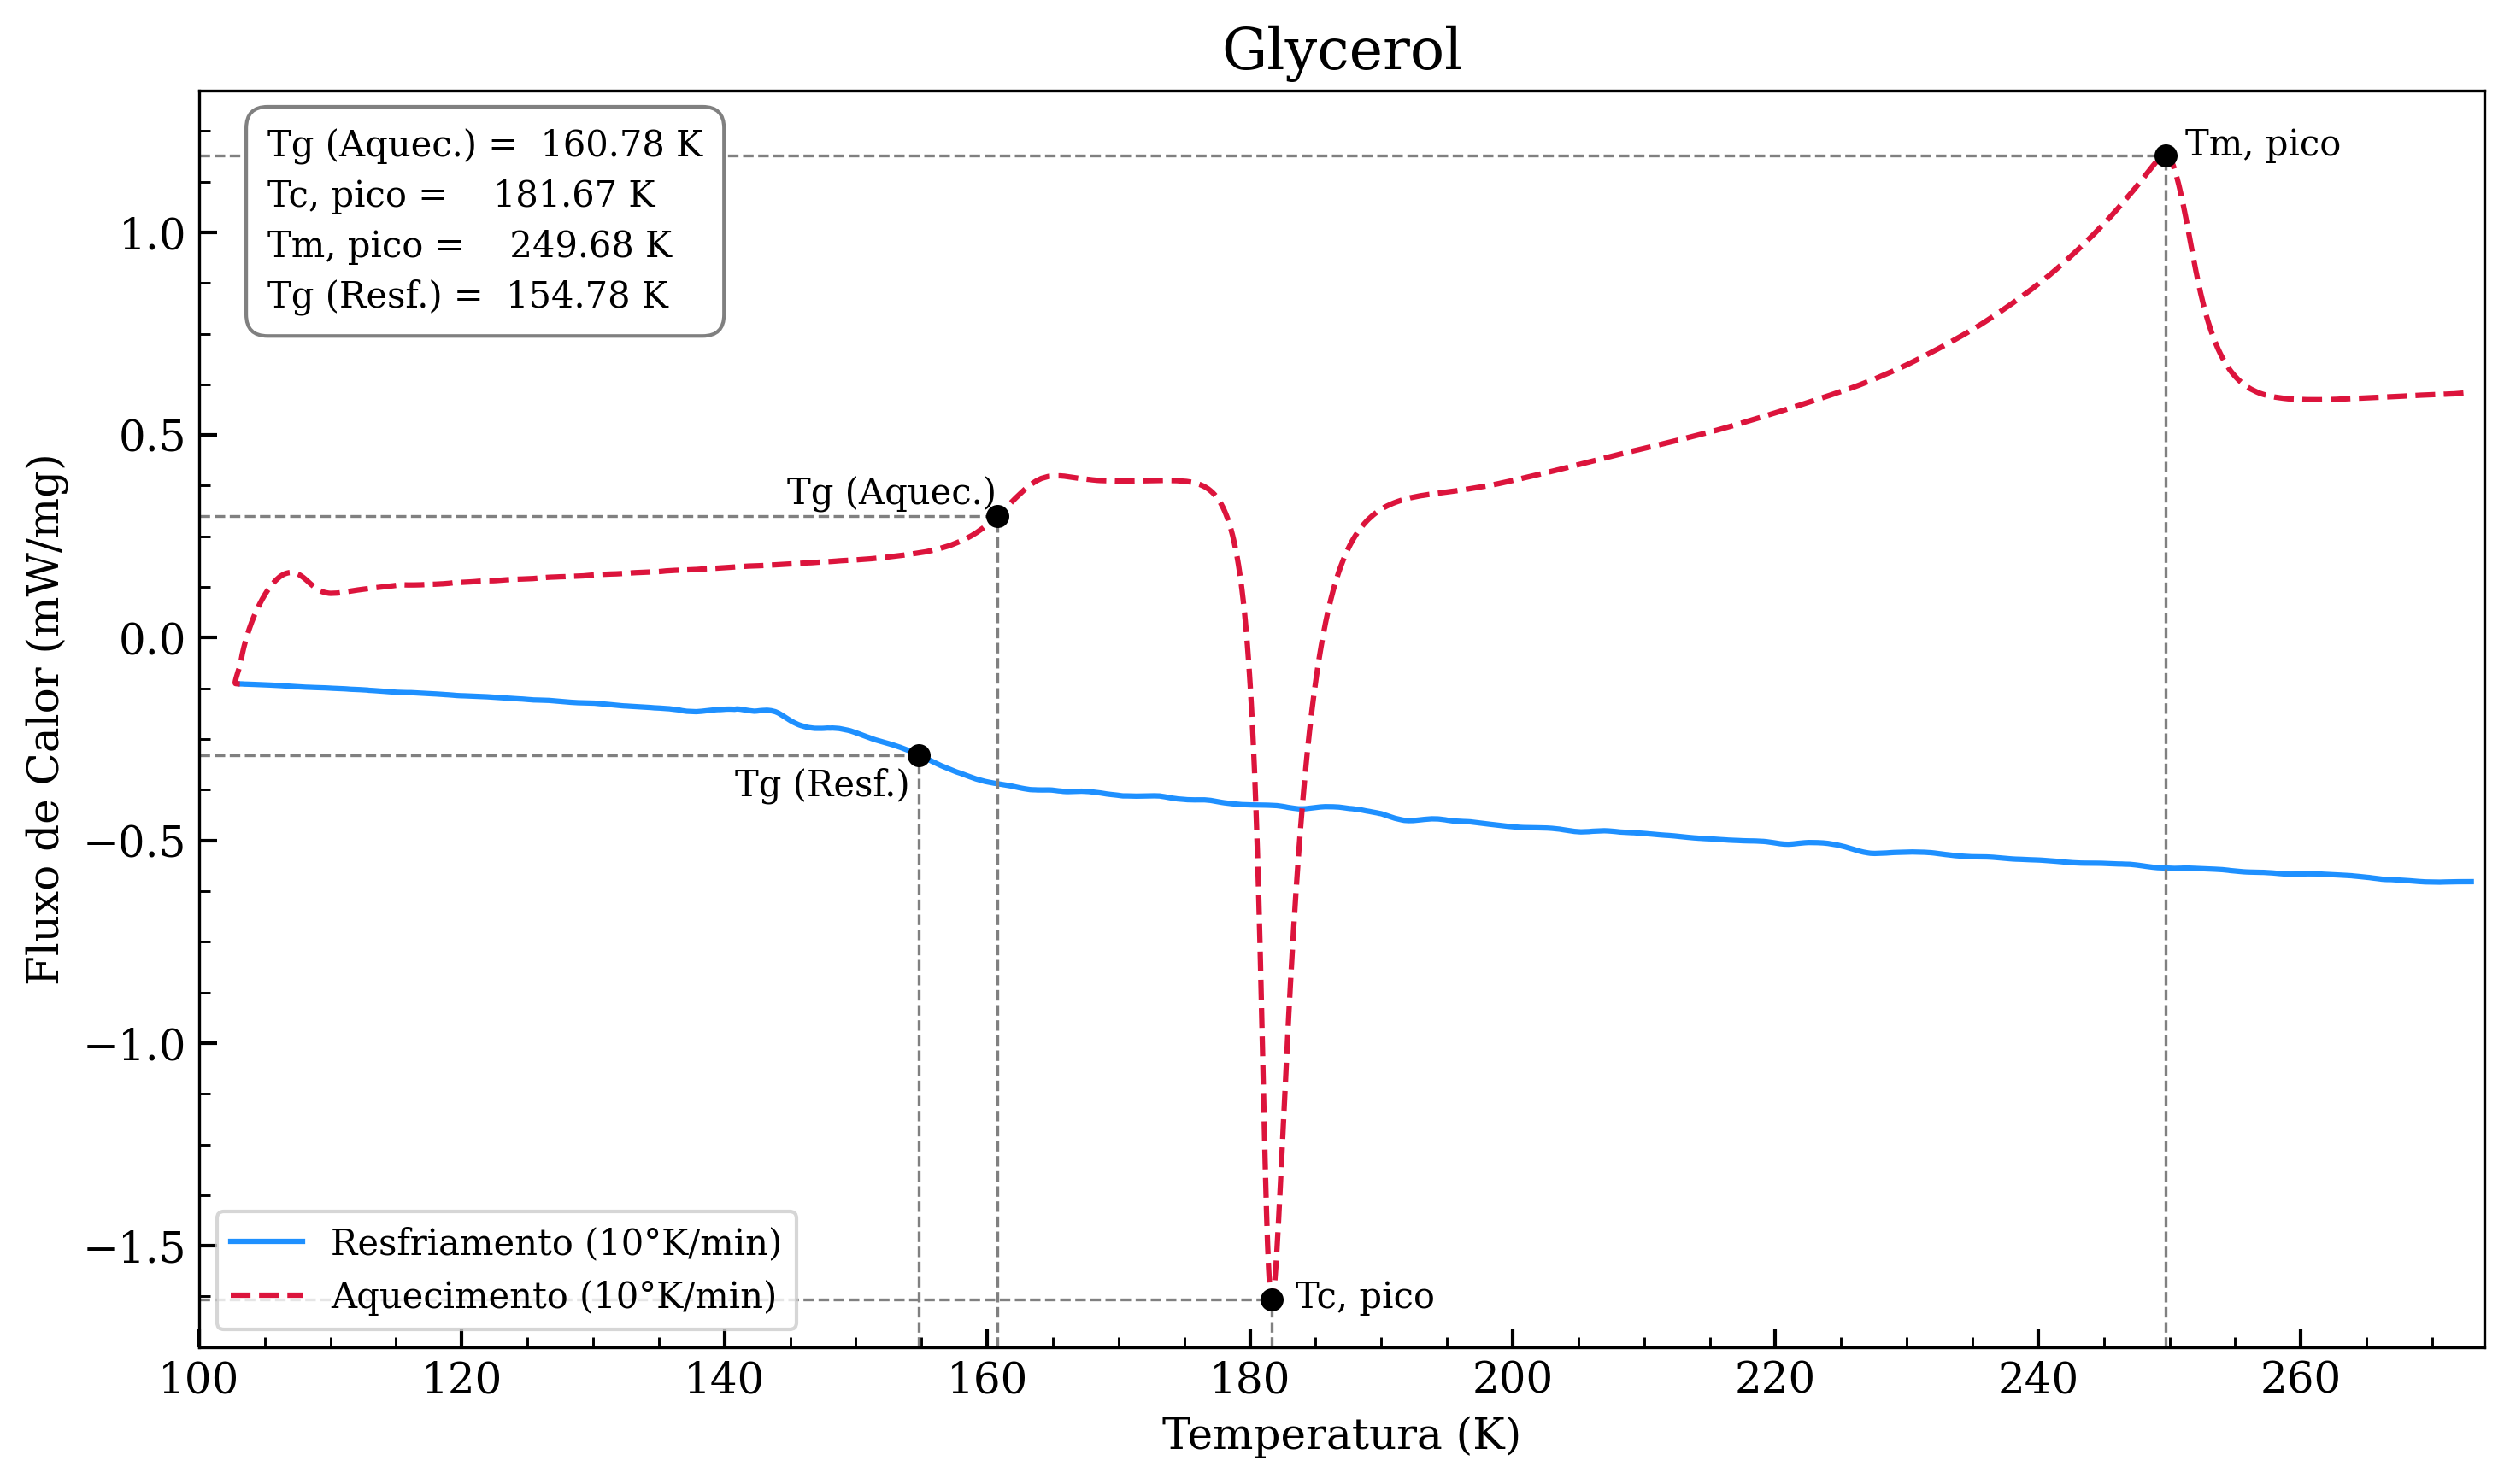

In [22]:
fig_gly_hepes = plota_dsc(
    titulo="Glycerol",
    df_resf=df_gly_hepes_resf, 
    df_aquec=df_gly_hepes_aquec,
    range_temp_resf=(100, 273),
    range_temp_aquec=(100, 273),
    pontos=pontos_plot,
    y_lim=(-1.75, 1.35),
    x_lim=(100, 274),
    x_text_shifts=[-16, +1.8, +1.5, -14],
    y_text_shifts=[+0.03, -0.02, 0, -0.1],
    posicao_quadro=(0.03, 0.97)
)

path_gly_hepes = "../resultados/dsc/plot_dsc_gly_hepes.svg"
plt.savefig(path_gly_hepes, format="svg", transparent=False, bbox_inches="tight", dpi=600)
plt.show() 

## **CSV - Resultados**

In [23]:
todas_as_amostras = {
    "Vs55 (Hepes)": todos_resultados_vs55,
    "Dp6 (Hepes)": todos_resultados_dp6,
    "Veg (Hepes)": todos_resultados_veg,
    "Glicerol (Hepes)": todos_resultados_gly,
}

df_tabela = gerar_tabela_resultados(todas_as_amostras)

display(df_tabela)

pasta_tabelas = "../resultados/dsc"
os.makedirs(pasta_tabelas, exist_ok=True)

caminho_arquivo = f"{pasta_tabelas}/resultados_dsc.csv"

df_tabela.to_csv(
    caminho_arquivo, 
    index=False,     
    sep=";",         
    decimal=","      
)

,Amostra,Evento,Temp. Característica (K),Onset (K),Endset (K),Fluxo de Calor (mW/mg)
0,Vs55 (Hepes),Tg (Aquec.),152.63,149.91,155.33,0.27
1,Vs55 (Hepes),"Tc, pico",212.06,192.16,244.45,0.28
2,Vs55 (Hepes),"Tm, pico",233.48,192.16,244.45,0.73
3,Vs55 (Hepes),Tg (Resf.),146.74,155.57,139.26,-0.25
4,Dp6 (Hepes),Tg (Aquec.),156.33,150.25,165.80,0.32
5,Dp6 (Hepes),"Tc, pico",205.19,192.90,243.16,-0.25
6,Dp6 (Hepes),"Tm, pico",244.89,216.27,253.03,0.98
7,Dp6 (Hepes),Tg (Resf.),150.67,156.41,144.29,-0.32
8,Veg (Hepes),Tg (Aquec.),146.93,144.20,149.42,0.26
9,Veg (Hepes),"Tc, pico",194.99,182.63,206.89,-0.22
